## Imports

In [1]:
!{sys.executable} -m pip install lightgbm

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [18]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


## Import data files

In [2]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"
train_path = DATA_DIR / "train_processed.csv"
test_path = DATA_DIR / "test_processed.csv"

## Define RMSPE Metric

In [3]:
def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

## Load Data

In [4]:
train = pd.read_csv(train_path, low_memory=False, parse_dates=["Date"])
test = pd.read_csv(test_path, low_memory=False, parse_dates=["Date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1017209, 18)
Test shape: (41088, 16)


In [19]:
train.head(10)

,Unnamed: 0,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,is_Promo2_known,months_since_Promo2,is_competition_open_known,months_since_competition_open,Year,Month,Day,WeekOfYear,DayOfYear,IsMonthStart,IsMonthEnd
0,1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,0,0,0.00,1,24027.0,2013,1,1,1,1,1,0
1,1016179,85,2,2013-01-01,4220,619,1,0,a,1,b,a,1870.0,0,0,0.00,1,24142.0,2013,1,1,1,1,1,0
2,1016353,259,2,2013-01-01,6851,1444,1,0,a,1,b,b,210.0,0,0,0.00,0,0.0,2013,1,1,1,1,1,0
3,1016356,262,2,2013-01-01,17267,2875,1,0,a,1,b,a,1180.0,0,0,0.00,1,24161.0,2013,1,1,1,1,1,0
4,1016368,274,2,2013-01-01,3102,729,1,0,a,1,b,b,3640.0,1,1,24158.50,0,0.0,2013,1,1,1,1,1,0
5,1016429,335,2,2013-01-01,2401,482,1,0,a,1,b,a,90.0,1,1,24163.75,0,0.0,2013,1,1,1,1,1,0
6,1016447,353,2,2013-01-01,3139,820,1,0,a,1,b,b,900.0,1,1,24159.50,0,0.0,2013,1,1,1,1,1,0
7,1016517,423,2,2013-01-01,9643,1751,1,0,a,1,b,a,1270.0,0,0,0.00,1,24173.0,2013,1,1,1,1,1,0
8,1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,b,1430.0,0,0,0.00,0,0.0,2013,1,1,1,1,1,0
9,1016606,512,2,2013-01-01,2646,625,1,0,a,1,b,b,590.0,1,1,24157.25,0,0.0,2013,1,1,1,1,1,0


In [20]:
test.head(10)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,is_Promo2_known,months_since_Promo2,is_competition_open_known,months_since_competition_open,Year,Month,Day,WeekOfYear,DayOfYear,IsMonthStart,IsMonthEnd
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,0,0,0.00,1,24105.0,2015,9,17,38,260,0,0
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,1,1,24135.50,1,24084.0,2015,9,17,38,260,0,0
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,0,0,0.00,1,24160.0,2015,9,17,38,260,0,0
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,0,0,0.00,1,24178.0,2015,9,17,38,260,0,0
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,0,0,0.00,1,24008.0,2015,9,17,38,260,0,0
5,6,10,4,2015-09-17,1.0,1,0,0,a,a,3160.0,0,0,0.00,1,24117.0,2015,9,17,38,260,0,0
6,7,11,4,2015-09-17,1.0,1,0,0,a,c,960.0,1,1,24144.25,1,24143.0,2015,9,17,38,260,0,0
7,8,12,4,2015-09-17,1.0,1,0,0,a,c,1070.0,1,1,24123.25,0,0.0,2015,9,17,38,260,0,0
8,9,13,4,2015-09-17,1.0,1,0,0,d,a,310.0,1,1,24119.25,0,0.0,2015,9,17,38,260,0,0
9,10,14,4,2015-09-17,1.0,1,0,0,a,a,1300.0,1,1,24142.00,1,24171.0,2015,9,17,38,260,0,0


## Basic Cleanup

In [5]:
train = train[train["Open"] == 1].copy()
train = train[train["Sales"] > 0].copy()

## Time Features

In [6]:
def add_time_features(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["DayOfYear"] = df["Date"].dt.dayofyear
    df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
    df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)
    return df

train = add_time_features(train)
test = add_time_features(test)

## Time-based split

In [7]:
train = train.sort_values("Date").reset_index(drop=True)
split_date = train["Date"].quantile(0.8)

train_part = train[train["Date"] < split_date].copy()
valid_part = train[train["Date"] >= split_date].copy()

## Target and features

In [8]:
X_train = train_part.drop(columns=["Sales", "Date"], errors="ignore")
y_train = train_part["Sales"]

X_valid = valid_part.drop(columns=["Sales", "Date"], errors="ignore")
y_valid = valid_part["Sales"]

X_test = test.drop(columns=["Id", "Date"], errors="ignore")

## Categorical columns

In [9]:
cat_cols = [
    c for c in [
        "StoreType",
        "Assortment",
        "StateHoliday",
        "PromoInterval"
    ]
    if c in X_train.columns
]

for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")
    if col in X_test.columns:
        X_test[col] = X_test[col].astype("category")

## Clean feature names for LightGBM

In [10]:
def clean_feature_names(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.replace(r"[^0-9a-zA-Z_]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

In [11]:
X_train = clean_feature_names(X_train)
X_valid = clean_feature_names(X_valid)
X_test = clean_feature_names(X_test)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

X_train: (674844, 23)
X_valid: (169494, 23)
X_test: (41088, 21)


## Model

In [12]:
model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse"
)

/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1632
[LightGBM] [Info] Number of data points in the train set: 674844, number of used features: 22
[LightGBM] [Info] Start training from score 6913.768455


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=2000,
              n_jobs=-1, num_leaves=64, random_state=42, subsample=0.8)

## Validation

In [13]:
valid_pred = model.predict(X_valid)
valid_pred = np.maximum(valid_pred, 0)

score_rmspe = rmspe(y_valid, valid_pred)
print(f"Validation RMSPE: {score_rmspe:.6f}")

Validation RMSPE: 0.071048


## Feature Importance

In [14]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum() * 100
)

print("\nTop 20 features:")
print(importance_df.head(20).to_string(index=False))

# Save table
importance_df.to_csv(DATA_DIR / "baseline_feature_importance.csv", index=False)


Top 20 features:
                      feature  importance  importance_pct
                    Customers       20412       16.200000
                        Store       20367       16.164286
          CompetitionDistance       19092       15.152381
months_since_competition_open       11713        9.296032
                    Unnamed_0        8319        6.602381
          months_since_Promo2        7467        5.926190
                    DayOfWeek        6436        5.107937
                    DayOfYear        6205        4.924603
                          Day        5256        4.171429
                        Promo        3713        2.946825
                    StoreType        3657        2.902381
                   WeekOfYear        3413        2.708730
                   Assortment        3259        2.586508
                       Promo2        1776        1.409524
                        Month        1367        1.084921
    is_competition_open_known        1142        0.906

## Plot Feature Importance

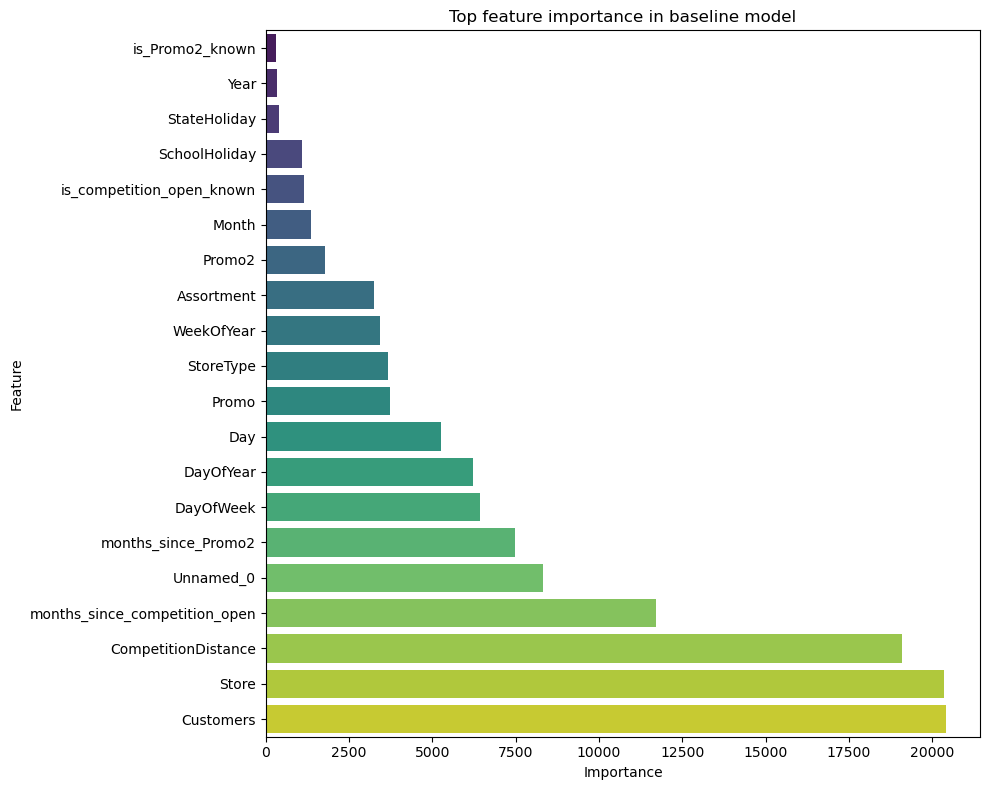

In [16]:
top_n = 20
plot_df = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x="importance", y="feature", hue="feature", palette="viridis")
plt.title("Top feature importance in baseline model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Main points

### Baseline results
The baseline model performs well for a first pass: the validation RMSPE is 0.0710, which indicates fairly strong predictive quality on the time-based holdout set. Since RMSPE is a relative-error metric, this means the model’s average percentage-level error is already quite low. 

The most important predictors are `Customers`, `Store`, `CompetitionDistance`, `months_since_competition_open`, `months_since_Promo2`, and calendar features such as `DayOfWeek`, `DayOfYear`, and `Day`. This suggests that the model is capturing both store-specific effects and time-related demand patterns.

One notable issue is that `Customers` is among the strongest features. In a strict forecasting setting, that may be problematic if `Customers` is not available at prediction time for the test period, so we need to verify whether it is a valid feature for the final submission pipeline. Also, `Unnamed_0` appears in the top features, which usually indicates an index column accidentally saved into the processed file and should be removed before final modeling.

The feature importance plot confirms that the model relies heavily on a small subset of strong predictors, while many others contribute only marginally. That is typical for boosted tree models and is a good sign that the model is learning meaningful structure rather than noise. 

### Next improvements

Next, we should improve the baseline in a few targeted ways. 
1) We should remove any leakage-prone or accidental columns such as `Unnamed_0`, and check whether `Customers` is safe to use at inference time.
2) We should add stronger time-series features, especially lag features and rolling statistics for sales, because those often improve retail forecasting more than simple calendar features.

After that, we can try a more careful validation strategy, for example a later time window or multiple time-based folds, to make sure the score is stable. Then we should tune LightGBM parameters and compare it with CatBoost and a simpler linear baseline to see whether the added complexity is actually giving better RMSPE.